In [13]:
import dd
from dd.cudd import BDD
import tqdm
import matplotlib.pyplot as plt

def ROBDD_div(n: int) -> dd.cudd.Function:
    bdd = BDD()
    bdd.configure(reordering=False)
    
    x_vars = [f'x{i}' for i in range(n)]
    y_vars = [f'y{i}' for i in range(n)]
    z_vars = [f'z{i}' for i in range(n)]

    list = x_vars + y_vars + z_vars
    
    bdd.declare(*list)
    
    formula = bdd.false
    counter = 0
    
    for x in tqdm.tqdm(range(2**n)):
        for y in range(1, 2**n):
            z = x // y
            r = x % y

            some_dict = {
                **{f'x{i}': bool((x >> i) & 1) for i in range(n)},
                **{f'y{i}': bool((y >> i) & 1) for i in range(n)},
                **{f'z{i}': bool((z >> i) & 1) for i in range(n)}
            }
            term = bdd.cube(some_dict)
            formula |= term
            counter += 1
    
    return (bdd, formula)


def calc_div(f, x: int, y: int, n: int) -> int:
    
    substitution = {
                **{f'x{i}': bool((x >> i) & 1) for i in range(n)},
                **{f'y{i}': bool((y >> i) & 1) for i in range(n)}
            }
    bdd = f.bdd
    
    result = bdd.let(substitution, f)

    z_val = 0
    for i in range(n):
        temp = bdd.let({f'z{i}': False}, result)
        if temp != bdd.false:
            result = temp
        else:
            z_val |= (1 << i)
            result = bdd.let({f'z{i}': True}, result)
    return z_val

def test_division(n):
    bdd, f = ROBDD_div(n)
    success = True
    
    for x in tqdm.tqdm(range(2**n)):
        for y in range(1, 2**n): 
            expected = x // y
            computed = calc_div(f, x, y, n)
            if(expected != computed):
                success = False
                print(f"Error x={x}, y={y}: expected {expected}, got {computed}")
    if(success):
        print("Tests success")

def res_in_I_division(a: int, b: int, n: int) -> dd.cudd.Function:
    bdd, f = ROBDD_div(n)

    max_val = (1 << n) - 1
    a = max(0, min(a, max_val))
    b = max(0, min(b, max_val))

    condition = bdd.false
    for z_val in range(a, b + 1):
        temp = bdd.cube({f'z{i}': bool((z_val >> i) & 1) for i in range(n)})
        condition |= temp

    result = bdd.exist([f'z{i}' for i in range(n)], f & condition)
    return result

import math
import numpy as np

def analyze_size(max_n):
    x_data = []
    y_data_nodes = []
    y_data_width = []
    for n in range(1, max_n):
        bdd, f = ROBDD_div(n)
        #print(bdd.vars)
        stats = bdd.statistics()
        #print(stats)
        print(f"Bits {n}:")
        print(f"  Nodes: {stats['n_nodes']}")
        print(f"  Peak nodes: {stats['peak_nodes']}")
        x_data.append(n)
        y_data_nodes.append(math.log2(stats['n_nodes']))
        y_data_width.append(math.log2(stats['peak_nodes']))
    plt.plot(x_data, y_data_nodes)
    plt.plot(x_data, y_data_width)
    plt.grid()
    plt.show()

def test_har(a, b, n):
    har = res_in_I_division(a, b, n)
    bdd, f = ROBDD_div(n)
    success = True
    for x in tqdm.tqdm(range(2**n)):
        for y in range(1, 2**n):
            substitution = {
                    **{f'x{i}': bool((x >> i) & 1) for i in range(n)},
                    **{f'y{i}': bool((y >> i) & 1) for i in range(n)}
                }
            bdd = har.bdd
            
            result = bdd.let(substitution, har)
            if(result == bdd.true):
                expected_z = calc_div(f, x, y, n)
                if not(expected_z >= a and expected_z <= b):
                    success = False
                    print(f"Error x={x} // y={y} does not lie in interval [a={a}, b={b}]")
    if(success):
        print("Haracteristics function is correct")


100%|██████████| 2/2 [00:00<00:00, 58254.22it/s]
/tmp/ipykernel_9604/1233501530.py:97: UserWarning: Changed in `dd` version 0.5.7: In the `dict` returned by the method `dd.cudd.BDD.statistics`, the value of the key `'mem'` has changed to bytes (from 10**6 bytes).
  stats = bdd.statistics()


Bits 1:
  Nodes: 10
  Peak nodes: 1022


100%|██████████| 4/4 [00:00<00:00, 66576.25it/s]


Bits 2:
  Nodes: 26
  Peak nodes: 1022


100%|██████████| 8/8 [00:00<00:00, 44034.69it/s]


...

Bits 7:
  Nodes: 2289
  Peak nodes: 22484


100%|██████████| 256/256 [00:00<00:00, 620.47it/s]


Bits 8:
  Nodes: 5676
  Peak nodes: 43946


100%|██████████| 512/512 [00:01<00:00, 304.58it/s]

Bits 9:
  Nodes: 13913
  Peak nodes: 58254


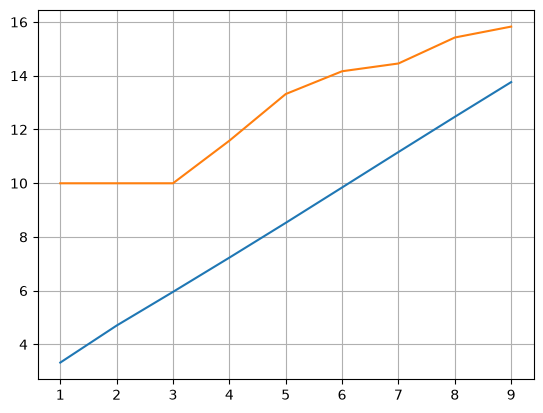

In [14]:
n = 10
analyze_size(n)

In [11]:
n = 10
test_division(n)

100%|██████████| 1024/1024 [00:14<00:00, 70.52it/s]

Tests success


In [12]:
n = 10
a = 1
b = 2
test_har(a, b, n)

100%|██████████| 1024/1024 [00:10<00:00, 95.77it/s]

Haracteristics function is correct
